# DEF-D Fysieke Ontwerpopdracht 4 invul template
Aan het einde van deze ontwerpopdracht lever je als groep één gezamenlijk notebook in. Zet jullie groepsnummer, studienummers en namen in onderstaande tabel zodat wij zeker weten dat het groepsvormen goed is gegaan.

| Groep: 51     |  |
| :-------------|:-------------|
| Kimi Hekmat| 6534759 |
| Frank de Kogel| 6582737 |
| Student naam 3| Student Studienummer 3 |

In [12]:
# Vul ook hieronder jullie voornamen in en run deze cel.
# Dat is nodig voor de code die je verderop in dit notebook gaat runnen.

studentNames = ['Kimi', 'Frank']

## Opdracht 1: Planning.

| Planning Groep: 51     |Tijdstip / Tijdspanne  |
|---|---|
| Mijlpaal 1 | 12:30 |
| Mijlpaal 2 | 16:30 |
| groep aanwezig 1| 13:30 |
| groep aanwezig 2| 16:15 |
| Pauze 1| 12:30-13:30 |
| Pauze 2| 16:00-16:15 |

## Opdracht 2: Import libs.

In [4]:
%matplotlib inline
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from scipy.optimize import curve_fit
import random
import time

# Dit is onze eigen library waar het imaging algoritme in staat
import imagingDEF2024 as imagingDEF

## Opdracht 3: Kalibratie sensor en foto

kalibratie-opstelling groep [51]
Bij onze kalibratieopstelling meten we enkel de afstand heen (er is geen afstand terug)
<img src="kalibratie_echo.jpeg" width="400">

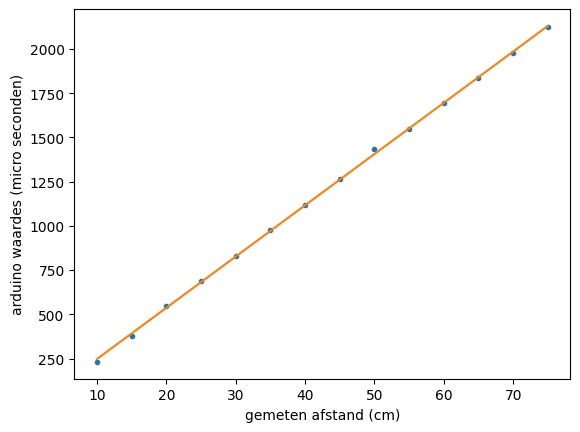

[ 28.97450549 -42.48791209]


In [ ]:
# verwerk hier jullie kalibratiemetingen

fysiek = np.array([10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70, 75]) # afstanden in centimeters (voorkant vericale platen)
arduino = np.array([231, 378, 549, 687, 830, 975, 1119, 1266, 1433, 1548, 1693, 1837, 1977, 2122]) # Meettijden in microseconden

def fit(x, a, b):
    return a*x + b

vals, covs = curve_fit(fit, fysiek, arduino)
xtest = np.linspace(np.min(fysiek), np.max(fysiek), 500)
ytest = fit(xtest, *vals)

plt.figure()
plt.plot(fysiek, arduino, '.', label = 'meetdata')
plt.plot(xtest, ytest, label = 'fit')
plt.xlabel('gemeten afstand (cm)')
plt.ylabel('arduino waardes (micro seconden)')
plt.show()

print(vals)

## Opdracht 4: Test meeting

Running the imaging algorithm with the following data:
   xs  ys  xr  yr     R
0   0  40   0  30  41.6
1   0  30   0  20  41.1
2  40   0  30   0  39.9
3  30   0  20   0  40.3


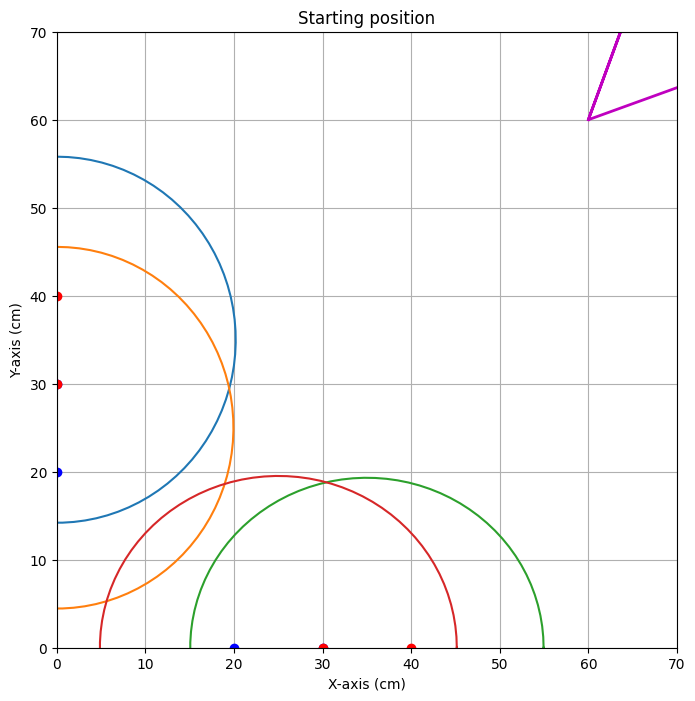


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=101.230


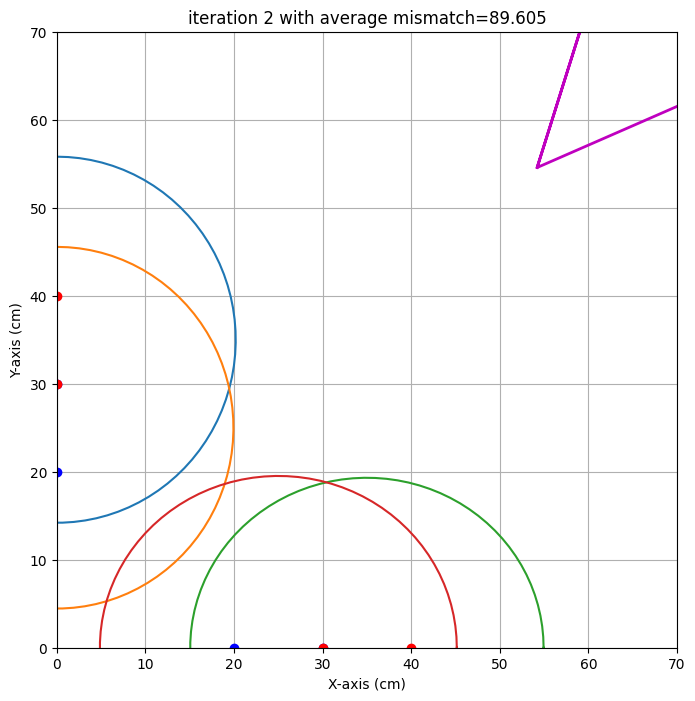

end iteration 2 with average mismatch=89.605


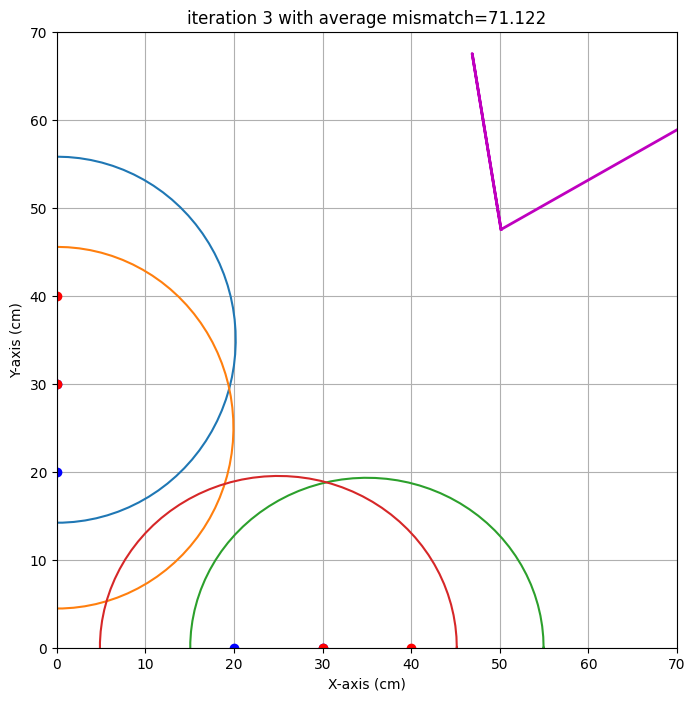

end iteration 3 with average mismatch=71.122


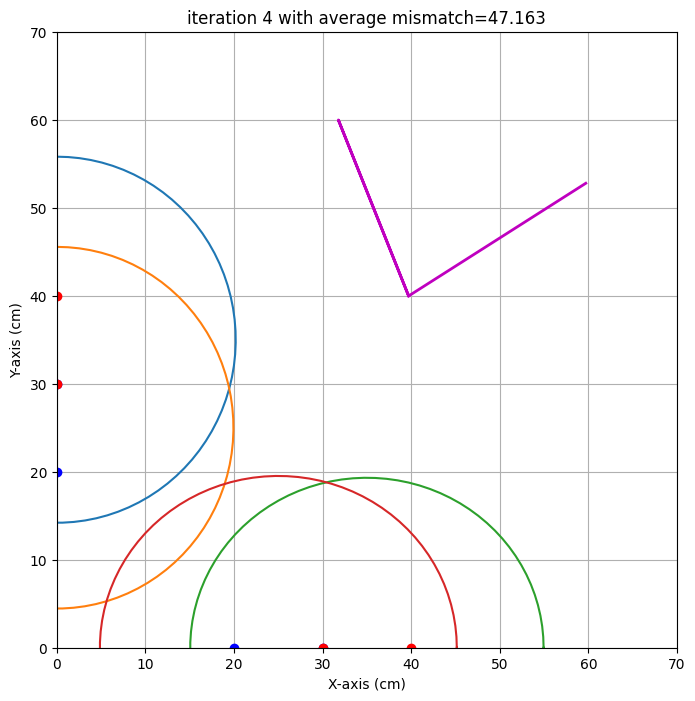

end iteration 4 with average mismatch=47.163


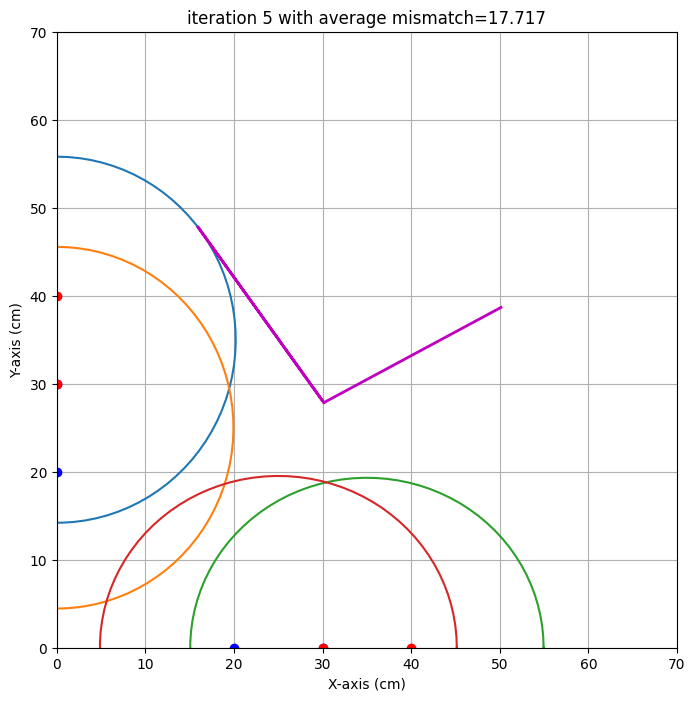

end iteration 5 with average mismatch=17.717


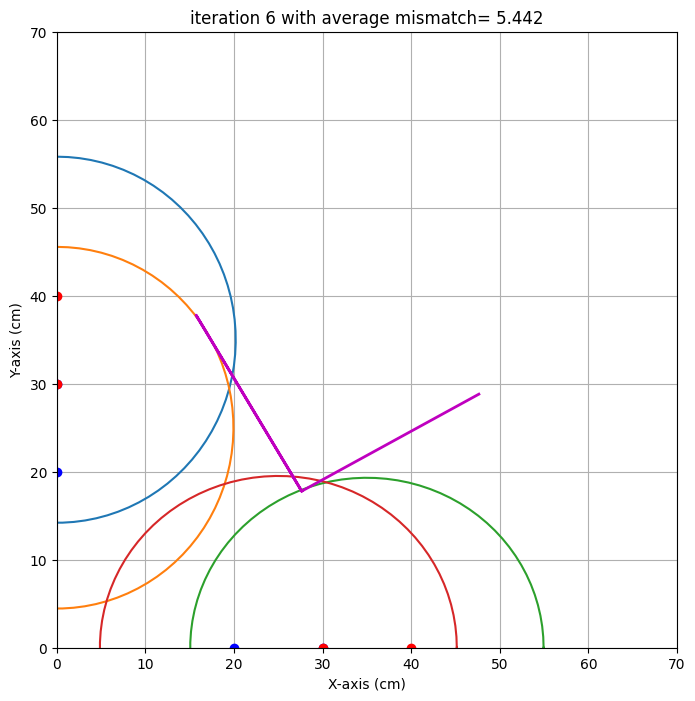

end iteration 6 with average mismatch= 5.442
end iteration 7 with average mismatch= 5.385
end iteration 8 with average mismatch= 5.312


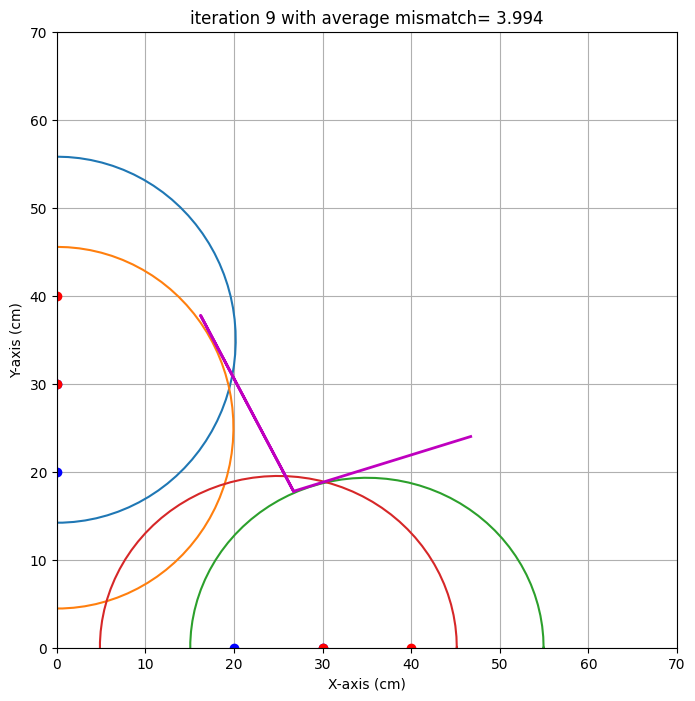

end iteration 9 with average mismatch= 3.994


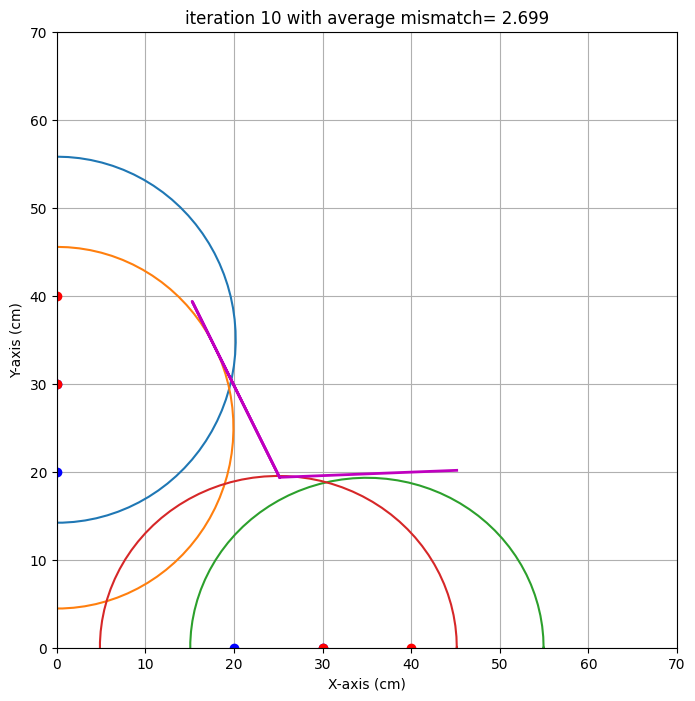

end iteration 10 with average mismatch= 2.699


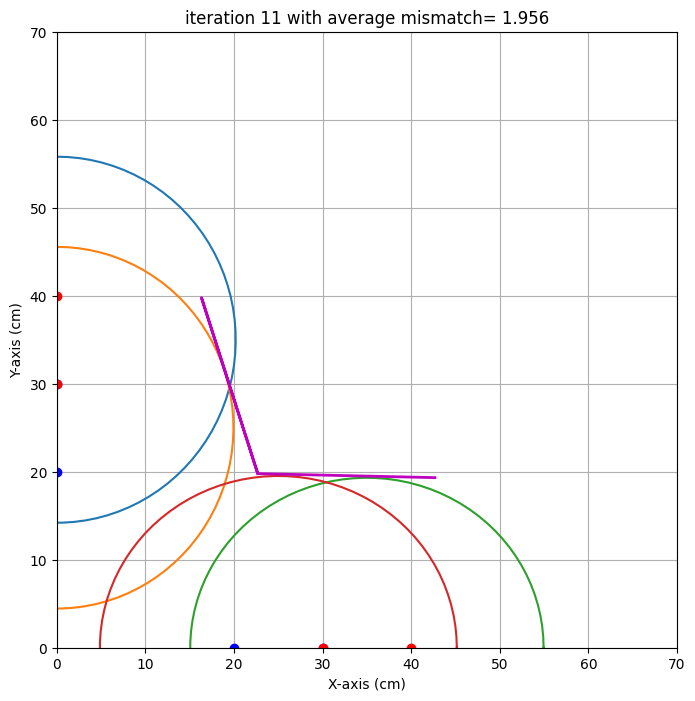

end iteration 11 with average mismatch= 1.956
end iteration 12 with average mismatch= 1.884


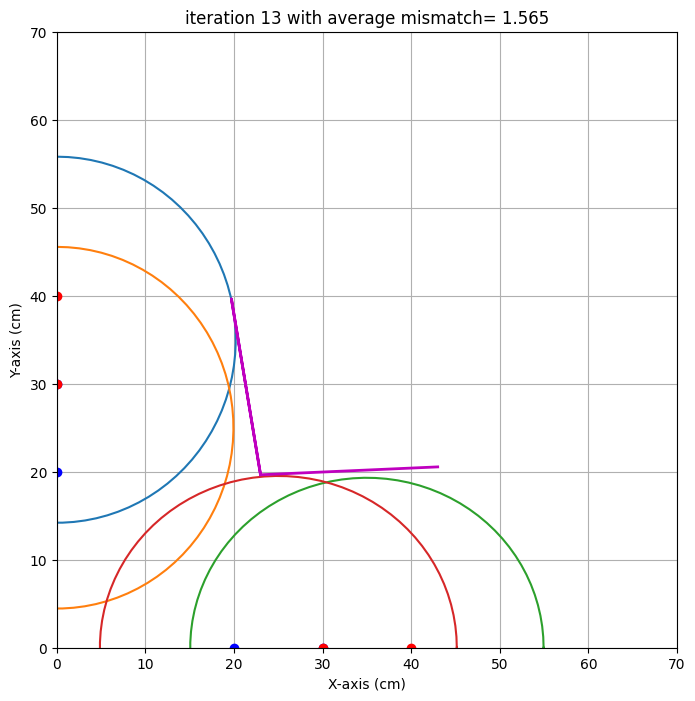

end iteration 13 with average mismatch= 1.565


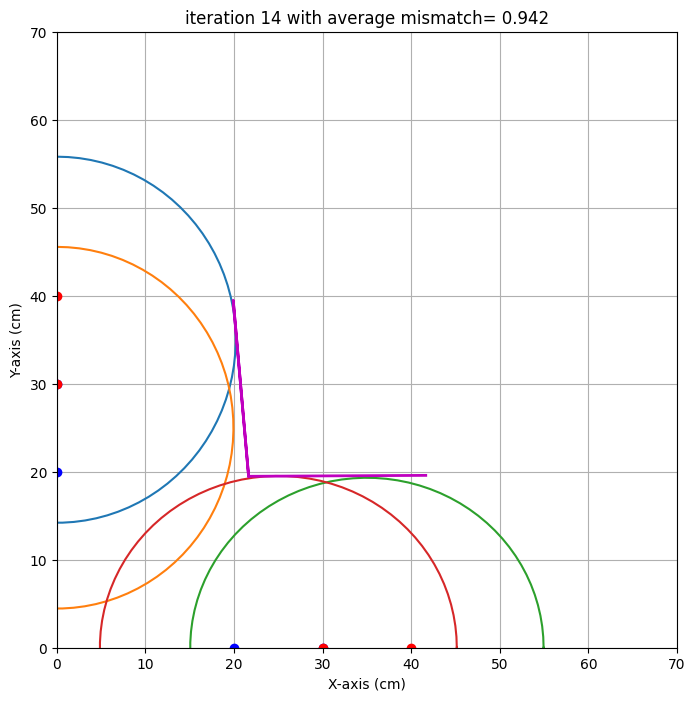

end iteration 14 with average mismatch= 0.942


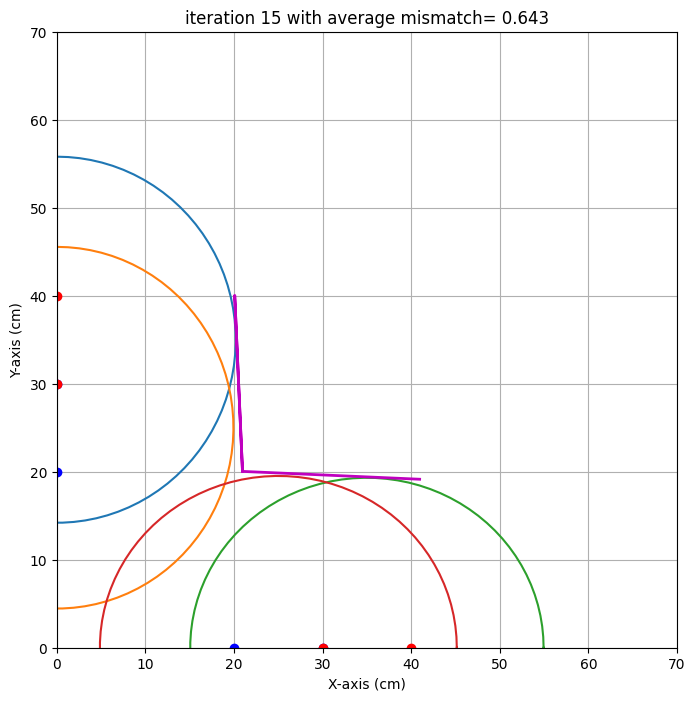

end iteration 15 with average mismatch= 0.643


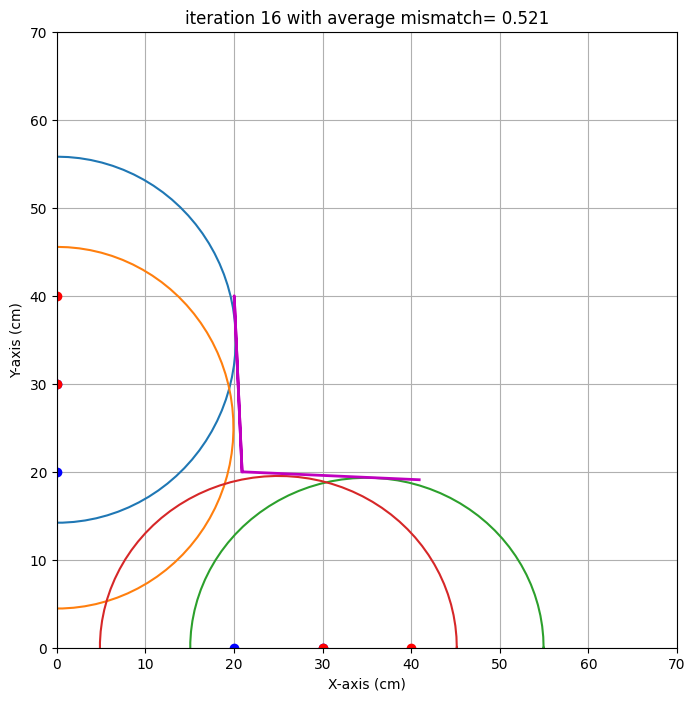

end iteration 16 with average mismatch= 0.521
end iteration 17 with average mismatch= 0.480
end iteration 18 with average mismatch= 0.458


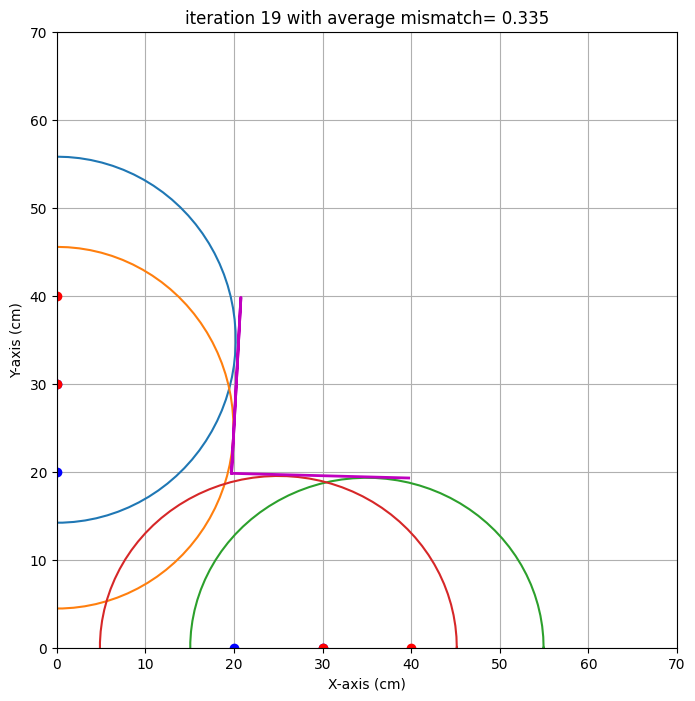

end iteration 19 with average mismatch= 0.335


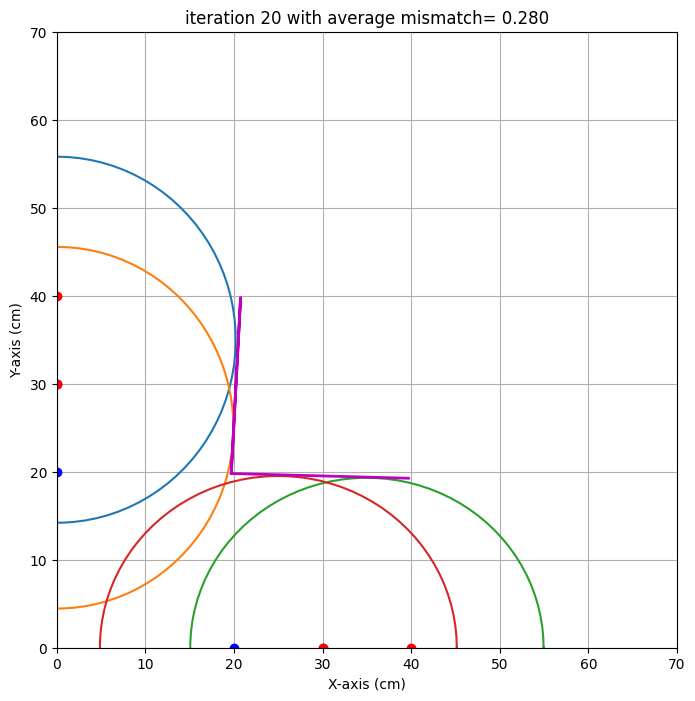

end iteration 20 with average mismatch= 0.280
end iteration 21 with average mismatch= 0.273
end iteration 22 with average mismatch= 0.271
end iteration 23 with average mismatch= 0.271
end iteration 24 with average mismatch= 0.271
end iteration 25 with average mismatch= 0.271
end iteration 26 with average mismatch= 0.271
end iteration 27 with average mismatch= 0.271
end iteration 28 with average mismatch= 0.271
end iteration 29 with average mismatch= 0.271
Last iteration, also determine uncertainty, wait a while..
wait a little longer....
wait a little longer....
wait a little longer....
end iteration 30 with average mismatch= 0.271
###############################################################################
end of iteration  30
Best alpha=  -1.54 with uncertainty=   0.85
Best beta =   3.02 with uncertainty=   2.03
Best x0   =  19.68 with uncertainty=   0.18
Best y0   =  19.79 with uncertainty=   0.02
###############################################################################


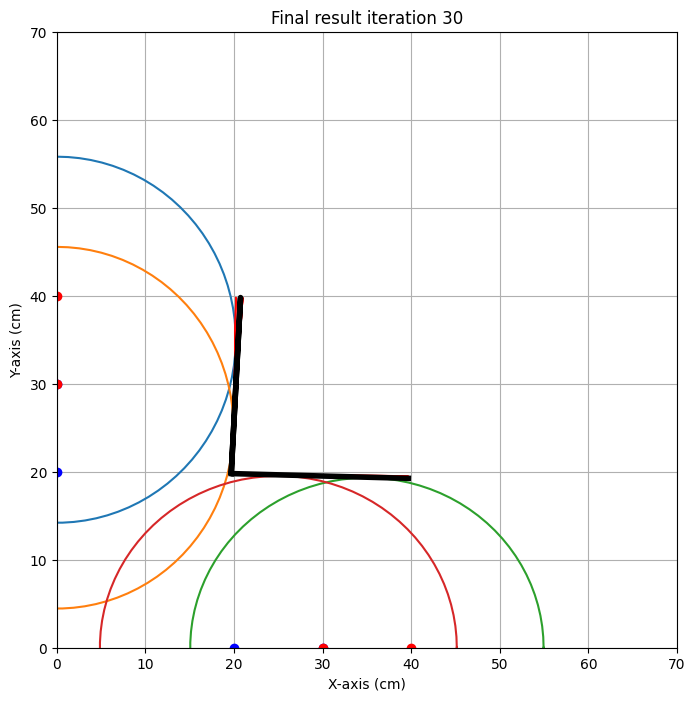

In [7]:
# Vul onderstaande matrixen aan met jullie meetgegevens.
# De getallen 1.0, 2.0, 3.0, 4.0, 5.0, 6.0 en 7.0 moet je door je eigen metingen (in cm!) vervangen.
# Let op dat de meting een totale afstand die het geluid afgelegd heeft moet zijn.

# Als je ongeldige metingen hebt (denk aan het college!), zet ze dan wel in het dataframe hieronder,
# maar gebruik een '#' om de regel uit te commenteren, zoals we bij de laatste meting voorgedaan hebben.

                
dataSanityCheck = pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    [0,40,0,30,41.6],
    [0,30,0,20,41.1],
    #[0,10,0,20,180], deze meting was onrealistisch, dus uitgecomment
    [40,0,30,0,39.9],
    [30,0,20,0,40.3],
    #[10,0,20,0,199.98], deze meting ongeldig voor dezelfde reden, hij pakt de hoek
    #[10,0,0,10,187.63], deze meting ongeldig, nam de hoek mee    
    ])

resultaatSanityCheck = imagingDEF.imagingDEF(dataSanityCheck)

In [5]:
# Run deze cel om jullie resultaten te kunnen zien.
txt='x0: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
txt = txt + 'y0: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
txt = txt + 'alpha: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
txt = txt + 'beta: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
print(txt.format(x0=resultaatSanityCheck['x0'],
                 x0_eps=resultaatSanityCheck['x0_eps'],
                 y0=resultaatSanityCheck['y0'],
                 y0_eps=resultaatSanityCheck['y0_eps'],
                 alpha=resultaatSanityCheck['alpha'],
                 alpha_eps=resultaatSanityCheck['alpha_eps'],
                 beta=resultaatSanityCheck['beta'],
                 beta_eps=resultaatSanityCheck['beta_eps']))

x0: 11.7 cm met een standaardafwijking van 4.2 cm 
y0: 8.8 cm met een standaardafwijking van 2.9 cm 
alpha: -26.6 graden met een standaardafwijking van 14.9 graad 
beta: -43.0 graden met een standaardafwijking van 13.8 graad 



## Opdracht 5: Iteratie 0

#### algoritme [naam eerste student]
Voeg een foto in van het algoritme van het eerste groepslid
<img src="tudelftLogo.png" width="400">

#### algoritme [naam tweede student]
Voeg een foto in van het algoritme van het tweede groepslid
<img src="tudelftLogo.png" width="400">

#### algoritme [naam derde student]
Voeg een foto in van het algoritme van het derde groepslid
<img src="tudelftLogo.png" width="400">

In [6]:
# Voeg hier eventueel code toe die je nodig hebt om je algoritme uit te voeren. Dit is optioneel!

## Opdracht 6: Test iteratie 0.

In [ ]:
# Voeg hier je meetgegevens van deze iteratie in:

# Vul onderstaande in met jullie gekozen posities van het reflecterende papier
targets = {'x0':35,
           'y0':32,#zelf aanvullen,
           'alpha' :30, #zelf aanvullen,
           'beta' : 0,#zelf aanvullen},
          }
           

# Vul onderstaande matrixen aan met je gemeten meetgegevens. Als je twee algoritmes test, haal dan het hele blok
# bij 'naam3' weg. Zorg natuurlijk dat de arrays en structures netjes afsluiten met ), ] of } op de juiste plekken.

data ={'Frank' :  pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    [40,0,50,0,72.4],
    [0,50,0,60,75.6],
    #[0,70,0,60,x]
    [0,45,0,55,74.7],
    [30,0,40,0,74.4],
    [50,0,60,0,75.2]
    ])
      }

## Opdracht 7: Evaluatie.

Kimi
Running the imaging algorithm with the following data:
   xs  ys  xr  yr     R
0  40   0  50   0  72.4
1   0  50   0  60  75.6
2   0  45   0  55  74.7
3  30   0  40   0  74.4
4  50   0  60   0  75.2


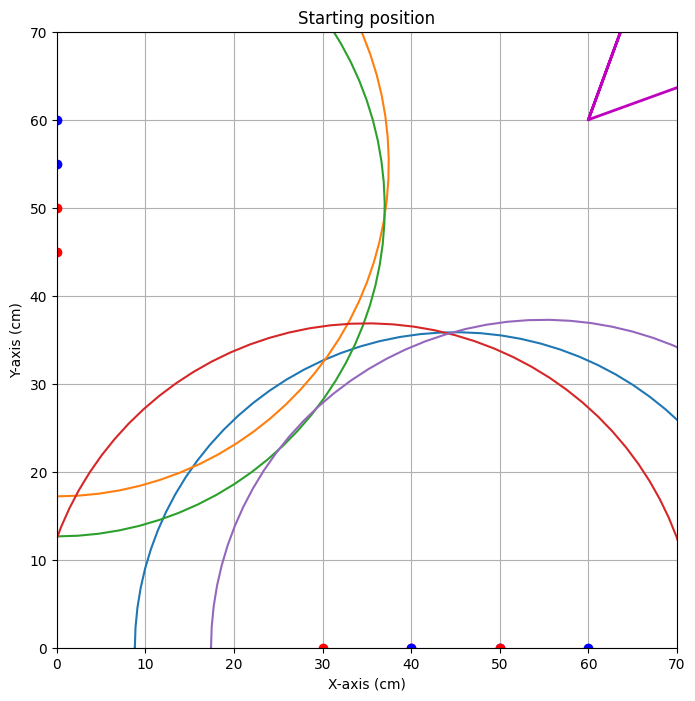


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=55.716


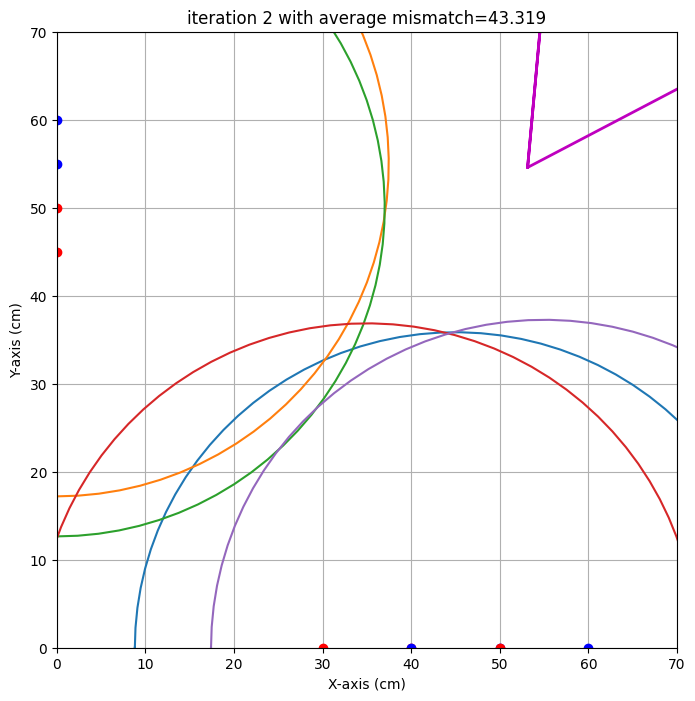

end iteration 2 with average mismatch=43.319


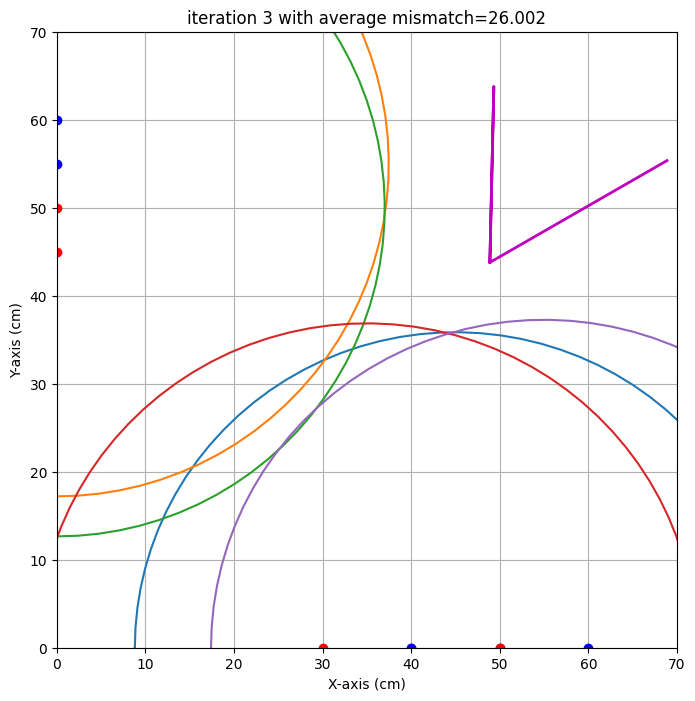

end iteration 3 with average mismatch=26.002


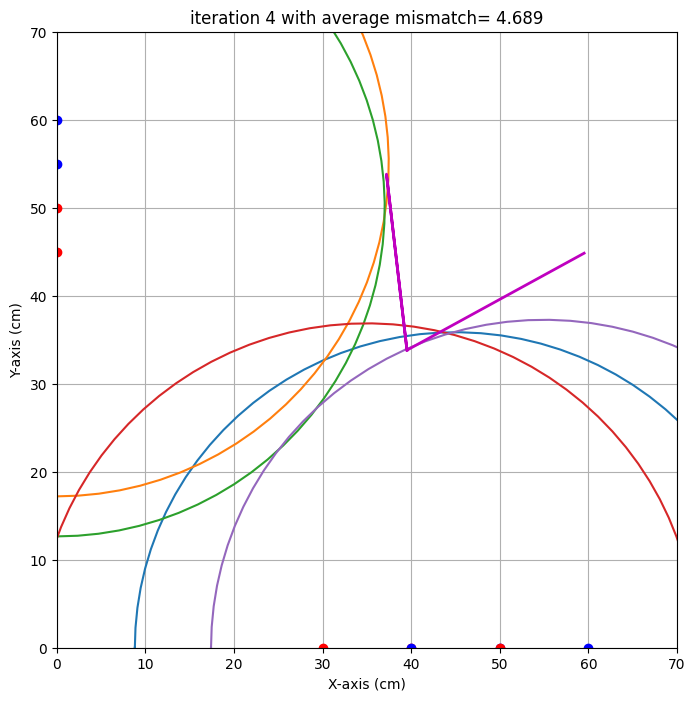

end iteration 4 with average mismatch= 4.689
end iteration 5 with average mismatch= 4.512


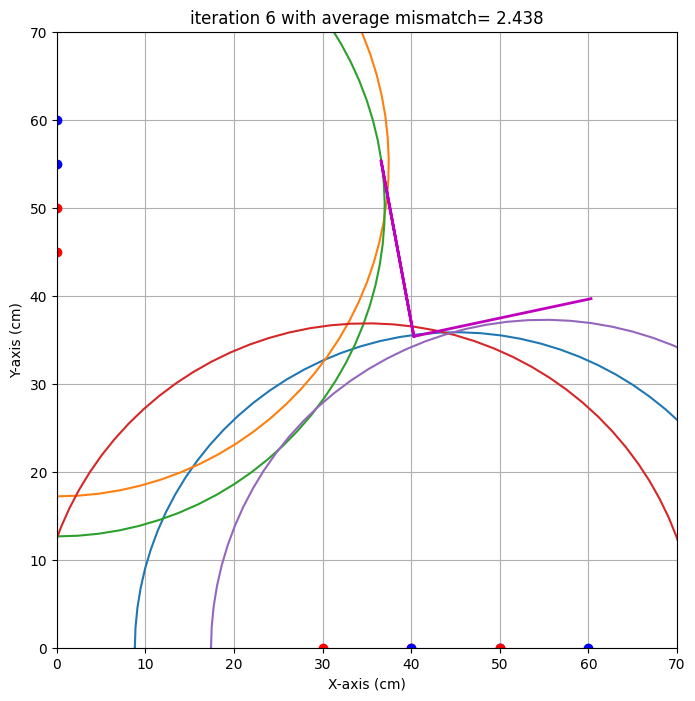

end iteration 6 with average mismatch= 2.438
end iteration 7 with average mismatch= 2.398
end iteration 8 with average mismatch= 2.359


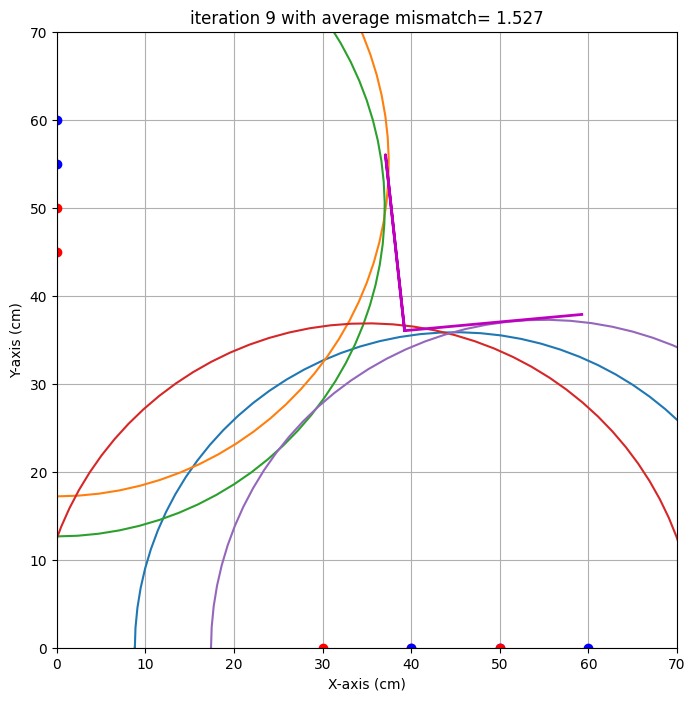

end iteration 9 with average mismatch= 1.527
end iteration 10 with average mismatch= 1.462
end iteration 11 with average mismatch= 1.458


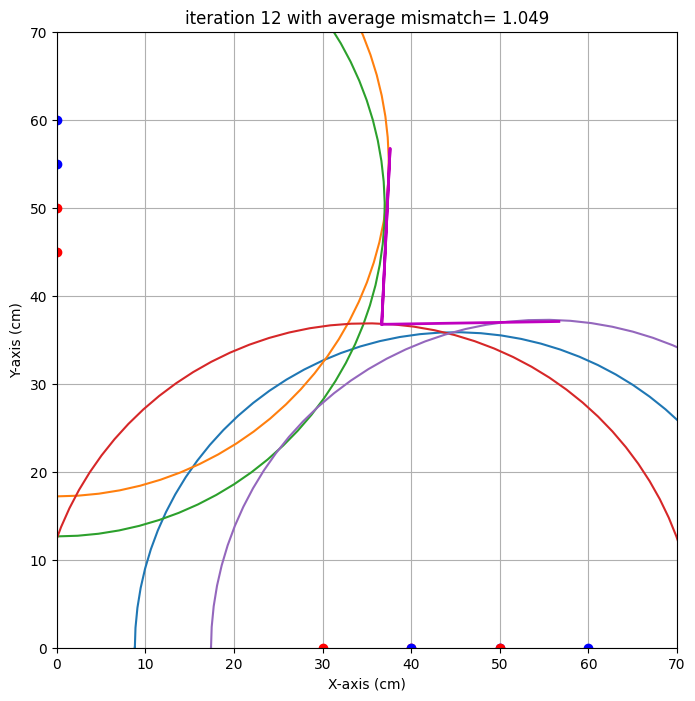

end iteration 12 with average mismatch= 1.049
end iteration 13 with average mismatch= 1.049
end iteration 14 with average mismatch= 0.972
end iteration 15 with average mismatch= 0.918
end iteration 16 with average mismatch= 0.918
end iteration 17 with average mismatch= 0.883
end iteration 18 with average mismatch= 0.869
end iteration 19 with average mismatch= 0.869
end iteration 20 with average mismatch= 0.869
end iteration 21 with average mismatch= 0.869
end iteration 22 with average mismatch= 0.869
end iteration 23 with average mismatch= 0.869
end iteration 24 with average mismatch= 0.869
end iteration 25 with average mismatch= 0.869
end iteration 26 with average mismatch= 0.869
end iteration 27 with average mismatch= 0.869
end iteration 28 with average mismatch= 0.845
end iteration 29 with average mismatch= 0.842
Last iteration, also determine uncertainty, wait a while..
wait a little longer....
wait a little longer....
end iteration 30 with average mismatch= 0.841
#################

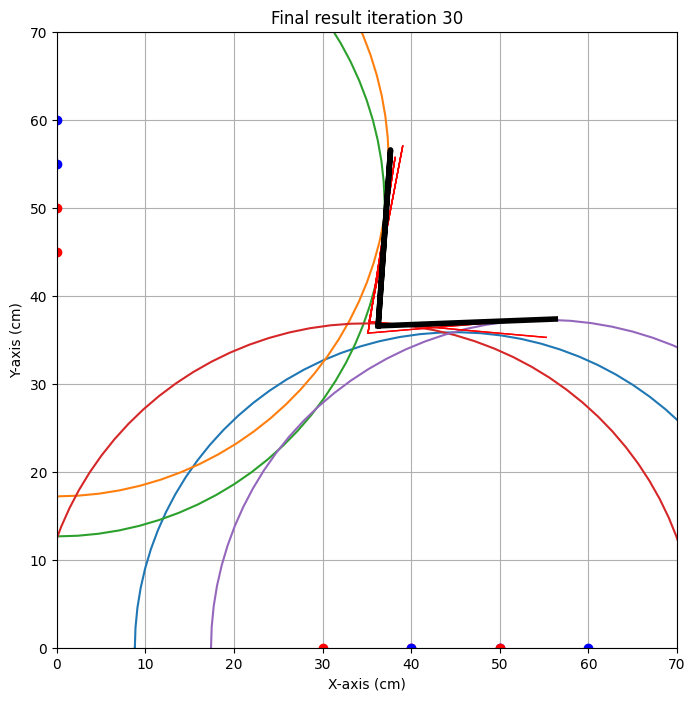

{'alpha': np.float64(2.2330378353102676), 'alpha_eps': np.float64(7.340883245308708), 'beta': np.float64(3.990811312996902), 'beta_eps': np.float64(6.761908960664947), 'x0': np.float64(36.27141386580473), 'x0_eps': np.float64(1.1483045024243523), 'y0': np.float64(36.57210448041921), 'y0_eps': np.float64(0.8195357888275083)}
Frank


KeyError: 'Frank'

In [15]:
# Hier runnen we het imaging algoritme:
resultaat = dict()

for studentName in studentNames:
    print(studentName)
    resultaat[studentName] = imagingDEF.imagingDEF(data[studentName])
    print(resultaat[studentName])

In [ ]:
# Run deze cel om jullie resultaten naast elkaar te kunnen zien.
for studentName in studentNames:
    txt='{naam} \r\nx0 target is : {x0Target:.1f}. Gevonden waarde: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
    txt = txt + 'y0 target is : {y0Target:.1f}. Gevonden waarde: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
    txt = txt + 'alpha target is : {alphaTarget:.1f}. Gevonden waarde: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
    txt = txt + 'beta target is : {betaTarget:.1f}. Gevonden waarde: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
    print(txt.format(naam = studentName,
                     x0Target=targets['x0'],
                     x0=resultaat[studentName]['x0'],
                     x0_eps=resultaat[studentName]['x0_eps'],
                     y0Target=targets['y0'],
                     y0=resultaat[studentName]['y0'],
                     y0_eps=resultaat[studentName]['y0_eps'],
                     alphaTarget=targets['alpha'],
                     alpha=resultaat[studentName]['alpha'],
                     alpha_eps=resultaat[studentName]['alpha_eps'],
                     betaTarget=targets['beta'],
                     beta=resultaat[studentName]['beta'],
                     beta_eps=resultaat[studentName]['beta_eps']))

NameError: name 'targets' is not defined

## Opdracht 8: Iteratie1+.VERVANG DEZE TEKST DOOR DE TIJD WANNEER JE AAN DEZE ITERATIE BEGINT.
### Synthese
Maak een nieuwe blokkenschema op A3 van wat je nu als algoritme gaat proberen. Als het kleine wijzigingen zijn ten opzichte van een vorige iteratie, kras dan gewoon in de oude blokkenschema als dat duidelijk blijft. Maak een foto en zet die hieronder. Zorg dat het iteratienummer goed op de foto te zien is.

Figuur: ![Alt](tudelftLogo.png)


In [ ]:
# Voeg hier eventueel (nieuwe) code toe die je nodig hebt om je algoritme uit te voeren. Dit is optioneel!

## Opdracht 9: Iteratie 1+ meeting en test

In [ ]:
# Voeg hier je meetgegevens van deze iteratie in:

# Vul onderstaande in met jullie gekozen locaties van het reflecterende papier.
targets = {'locatie 1':{'x0':#zelf aanvullen,
                    'y0':#zelf aanvullen,
                    'alpha' : #zelf aanvullen,
                    'beta' : #zelf aanvullen},
           'locatie 2':{'x0':#zelf aanvullen,
                    'y0':#zelf aanvullen,
                    'alpha' : #zelf aanvullen,
                    'beta' : #zelf aanvullen}
            }
           

# Vul onderstaande matrixen aan met je gemeten meetgegevens.

data ={'locatie 1' :  pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    # zelf aanvullen
    ]),
       'locatie 2' : pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    # zelf aanvullen
    ])
      }
                        
                        
# Hier runnen we het imaging algoritme:
resultaat = dict()

for locatie in targets:
    print(locatie)
    resultaat[locatie] = imagingDEF.imagingDEF(data[locatie])
    print(resultaat[locatie])

                        
# en hier laten we de resultaten als text zien.
for locatie in targets:
    txt='{naam} \r\nx0 target is : {x0Target:.1f}. Gevonden waarde: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
    txt = txt + 'y0 target is : {y0Target:.1f}. Gevonden waarde: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
    txt = txt + 'alpha target is : {alphaTarget:.1f}. Gevonden waarde: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
    txt = txt + 'beta target is : {betaTarget:.1f}. Gevonden waarde: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
    print(txt.format(naam = locatie,
                     x0Target=targets[locatie]['x0'],
                     x0=resultaat[locatie]['x0'],
                     x0_eps=resultaat[locatie]['x0_eps'],
                     y0Target=targets[locatie]['y0'],
                     y0=resultaat[locatie]['y0'],
                     y0_eps=resultaat[locatie]['y0_eps'],
                     alphaTarget=targets[locatie]['alpha'],
                     alpha=resultaat[locatie]['alpha'],
                     alpha_eps=resultaat[locatie]['alpha_eps'],
                     betaTarget=targets[locatie]['beta'],
                     beta=resultaat[locatie]['beta'],
                     beta_eps=resultaat[locatie]['beta_eps']))

SyntaxError: '{' was never closed (3018683157.py, line 4)

## Opdracht 10: Uiteindelijke test met locatie gegeven door TA

In [ ]:
# Voeg hier je meetgegevens van de uiteindelijke test in:

# Vul onderstaande in met jullie locaties van het reflecterende papier gegeven
# door jullie TA
targets = {'test locatie':{
                    'x0':  # zelf aanvullen,
                    'y0':  # zelf aanvullen,
                    'alpha' :  # zelf aanvullen,
                    'beta' :  # zelf aanvullen
                          }
            }
           

# Vul onderstaande matrixen aan met je gemeten meetgegevens.

dataFinalCheck ={'test locatie' :  pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
                    # zelf aanvullen
                    ])
                }

# Hier runnen we het imaging algoritme:
resultaat = dict()

for locatie in targets:
    print(locatie)
    resultaat[locatie] = imagingDEF.imagingDEF(dataFinalCheck[locatie])
    print(resultaat[locatie])

    
# Run deze cel om jullie resultaten naast elkaar te kunnen zien.
for locatie in targets:
    txt = '{naam} \r\nx0 target is : {x0Target:.1f}. Gevonden waarde: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
    txt = txt + 'y0 target is : {y0Target:.1f}. Gevonden waarde: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
    txt = txt + 'alpha target is : {alphaTarget:.1f}. Gevonden waarde: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
    txt = txt + 'beta target is : {betaTarget:.1f}. Gevonden waarde: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
    print(txt.format(naam = locatie,
                     x0Target=targets[locatie]['x0'],
                     x0=resultaat[locatie]['x0'],
                     x0_eps=resultaat[locatie]['x0_eps'],
                     y0Target=targets[locatie]['y0'],
                     y0=resultaat[locatie]['y0'],
                     y0_eps=resultaat[locatie]['y0_eps'],
                     alphaTarget=targets[locatie]['alpha'],
                     alpha=resultaat[locatie]['alpha'],
                     alpha_eps=resultaat[locatie]['alpha_eps'],
                     betaTarget=targets[locatie]['beta'],
                     beta=resultaat[locatie]['beta'],
                     beta_eps=resultaat[locatie]['beta_eps']))

SyntaxError: invalid syntax (598375666.py, line 7)

## Opdracht 11: Leerdoelen.
Figuur: ![Alt](tudelftLogo.png "Title")

Figuur: ![Alt](tudelftLogo.png "Title")

Figuur: ![Alt](tudelftLogo.png "Title")